In [11]:
import random

from minigrid.core.grid import Grid
from minigrid.core.world_object import *
from minigrid.minigrid_env import MiniGridEnv
from minigrid.core.mission import MissionSpace
import numpy as np

from config import CURRICULUM_REWARDS, CURRICULUM_STEPS
from envs.wrappers import ConvWrapper

import random

from minigrid.core.grid import Grid
from minigrid.core.world_object import *
from minigrid.minigrid_env import MiniGridEnv
from minigrid.core.mission import MissionSpace
import numpy as np

from config import CURRICULUM_REWARDS, CURRICULUM_STEPS
from envs.wrappers import ConvWrapper
from minigrid.core.constants import COLOR_NAMES

color_key = {
    "blue": "b",
    "green": "g",
    "grey": "z",
    "purple":"p",
    "red": "r",
    "yellow": "y"
}

color_door = {
    "blue": "B",
    "green": "G",
    "grey": "Z",
    "purple": "P",
    "red": "R",
    "yellow": "Y"
}

def place_objects(objs, grid, start_x, start_y, end_x, end_y, allow=None):
        for obj in objs:
            while True:
                x = random.randint(start_x, end_x)
                y = random.randint(start_y, end_y)
                if grid[x,y] == "." or (allow and grid[x,y] in allow):
                    grid[x,y] = obj
                    break
            

def random_key_door():
    color = random.choice(COLOR_NAMES)
    key_symbol = color_key[color]
    door_symbol = color_door[color]
    return key_symbol, door_symbol


def maze_backtrack(start_x, start_y, x_end, y_end, grid, point_1, point_2):
    lower_bound_x = min(start_x, x_end)
    upper_bound_x = max(start_x, x_end)
    lower_bound_y = min(start_y, y_end)
    upper_bound_y = max(start_y, y_end)

    seen = set([point_1])
    stack = [(point_1, [point_1])]

    safe_path = []

    while stack:
        (x, y), current_path = stack.pop()
        
        if (x, y) == point_2:
            safe_path = current_path
            break
            
        neighbors = [(x + 1, y), (x, y + 1), (x - 1, y), (x, y - 1)]
        random.shuffle(neighbors)

        for nx, ny in neighbors:
            if lower_bound_x <= nx <= upper_bound_x and lower_bound_y <= ny <= upper_bound_y:
                if (nx, ny) not in seen:
                    seen.add((nx, ny))
                    stack.append(((nx, ny), current_path + [(nx, ny)]))
                
    for x, y in safe_path:
        grid[x, y] = "."
       

class Room:

    def generate(self):
        pass

class BasicRoom(Room):

    def __init__(self):

        self.room_string = """#######
        #.....#
        #.....+
        #.....#
        #######
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
      
        random_row = random.randint(1, grid.shape[0] - 2)
        random_col = random.randint(1, grid.shape[1] - 2)
        grid[random_row, random_col] = "A"
        return grid



class KeyDungeon(Room): 
    def __init__(self):

        self.room_string = """
        #######
        #.....#
        #.....#
        #.....#
        #.....#
        #.....#
        #######
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
       
        agent_x = random.randint(3, 4)
        agent_y = random.randint(1,2)
        
        key_x = random.choice([1,5])
        key_y = random.randint(1,5)

        grid[agent_x, agent_y] = "A"
        grid[key_x, key_y] = "K"

        return grid



class LavaMazeGoal(Room): 
    def __init__(self):

        self.room_string = """
        #########################################
        #.....#..........................#......#
        #.....#..........................#......#
        #.....#..........................##+##+##
        #LLLLL#..........................#......#
        #.....#..........................#......#
        #LLLLL#..........................##+##+##
        #.....#..........................#......#
        #LLLLL#..........................#......#
        #.....#..........................#......#
        #.....#..........................#......#
        #########################################
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
       
        agent_x = random.randint(1, 2)
        grid[agent_x, random.randint(1,4)] = "A"

        lava_gap_x = [4,6,8]
        lava_gap_y = [random.randint(1,5),random.randint(1,5),random.randint(1,5)]
        grid[lava_gap_x, lava_gap_y] = "."
        random_key_x, random_key_y = random.randint(9,10), random.randint(1,5)
        

        key_symbol, door_symbol = random_key_door()
        grid[random_key_x, random_key_y] = key_symbol
        y_door = 6
        x_door = random.randint(1,3)
        grid[x_door, y_door] = door_symbol

        random_obstacles_y = np.random.randint(8, 32 , (130))
        random_obstacles_x = np.random.randint(1,10, (130))
        grid[random_obstacles_x, random_obstacles_y] = "#"

        random_key_maze_y = random.randint(12, 30)
        random_key_maze_x = random.randint(1,10)
        
        random_door_x = random.randint(2, 10)
        door_y = 33

        key_symbol, door_symbol = random_key_door()
        grid[random_door_x, door_y] = door_symbol
        maze_backtrack(2, 7, 10, 32, grid, destination=(random_key_maze_x, random_key_maze_y))
        maze_backtrack(random_key_maze_x, random_key_maze_y, random_door_x, door_y -1 , grid, destination=(random_door_x, door_y -1))
        grid[random_key_maze_x, random_key_maze_y] = key_symbol
        
        goal_x = random.choice([1,2,4,5,7,8,9,10])
        goal_y = random.randint(34,39)
        
        grid[goal_x, goal_y] = "D"
        return grid


class Obstacles(Room):
    
    def __init__(self):

        self.string= """
        ######
        #....#
        #....#
        #....#
        ######
        """.strip()

    def generate(self):        
        grid = np.array([list(row.strip()) for row in self.string.splitlines()])

        obj = ["A", "D"]
        for _ in range(8):
            obj.append("-")

        place_objects(obj, grid, 1,1,3,4)
        return grid



class Obstacles1(Room):

            
    def __init__(self):

        self.string= """
        ########
        #......#
        #......#
        #......#
        #......#
        ########
        """.strip()

    def generate(self):        
        grid = np.array([list(row.strip()) for row in self.string.splitlines()])

        obj = ["A", "D"]
        for _ in range(15):
            obj.append("-")

        place_objects(obj, grid, 1,1,4,6)
        return grid

class Obstacles2(Room):

            
    def __init__(self):

        self.string= """
        ##########
        #--------#
        #--------#
        #--------#
        #--------#
        #--------#
        #--------#
        ##########
        """.strip()

    def generate(self):        
        grid = np.array([list(row.strip()) for row in self.string.splitlines()])

        obj = ["A", "D"]

        place_objects(obj, grid, 1,1,7,9, allow=["-"])

        return grid


class dungeon_2(Room): 


            
    def __init__(self):

        self.second_string= """
        #########################################
        #L....#..........................#......#
        #L....#..........................#......#
        #L...L############################......#
        #L...L#.................................#
        #L...L#.................................#
        #L...L#.................................#
        #L#+#L#...............##############+####
        #L...L#...............#.................#
        #L...L#...............#.................#
        #L...L#...............#.................#
        #########################################
        """.strip()
    
    
    def generate(self):
        
        second_grid = np.array([list(row.strip()) for row in self.second_string.splitlines()])
        second_grid[random.randint(2,4), random.randint(33,38)] = "A"
        keys = []
        important_key, important_door = random_key_door()
        second_important_key, second_important_door = random_key_door()
        keys.append(important_key)
        keys.append(second_important_key)

        second_grid[3,30] = important_door
        second_grid[1,6] = second_important_door
        for _ in range(2):
            keys.append(random_key_door()[0])
        
        one_key = keys.pop()

        place_objects(keys, second_grid, 4, 7, 10, 20)
        place_objects([one_key], second_grid, 8, 23, 10, 40)

        obstacles = ["-" for _ in range(45)]
        place_objects(obstacles, second_grid, 4, 7, 10, 20)

     
        return second_grid


class dungeon_3(Room): 


    def __init__(self):

        self.room_string = """
        #########################################
        #.....#..........................#......#
        #.....#..........................#......#
        #.....#..........................#......#
        #LLLLL#..........................#......#
        #.....#..........................#......#
        #LLLLL#..........................#......#
        #.....#..........................#......#
        #LLLLL#..........................#......#
        #.....#..........................#......#
        #.....#..........................#......#
        ##################################......#
        """.strip()

        self.second_string= """
        ##################################......#
        #L....#..........................#......#
        #L....#..........................#......#
        #L...L############################......#
        #L...L#.................................#
        #L...L#.................................#
        #L...L#.................................#
        #L#+#L#...............##############+####
        #L...L#...............#.................#
        #L...L#...............#.................#
        #L...L#...............#.................#
        #########################################
        """.strip()
    
    
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
       
        agent_x = random.randint(1, 2)
        grid[agent_x, random.randint(1,4)] = "A"

        lava_gap_x = [4,6,8]
        lava_gap_y = [random.randint(1,5),random.randint(1,5),random.randint(1,5)]
        grid[lava_gap_x, lava_gap_y] = "."
        random_key_x, random_key_y = random.randint(9,10), random.randint(1,5)
        

        key_symbol, door_symbol = random_key_door()
        grid[random_key_x, random_key_y] = key_symbol
        y_door = 6
        x_door = random.randint(1,3)
        grid[x_door, y_door] = door_symbol

        random_obstacles_y = np.random.randint(8, 32 , (120))
        random_obstacles_x = np.random.randint(1,11, (120))
        grid[random_obstacles_x, random_obstacles_y] = "#"

        random_key_maze_y = random.randint(12, 30)
        random_key_maze_x = random.randint(1,10)
        
        random_door_x = random.randint(2, 10)
        door_y = 33

        key_symbol, door_symbol = random_key_door()
        grid[random_door_x, door_y] = door_symbol
        maze_backtrack(2, 7, 10, 32, grid, destination=(random_key_maze_x, random_key_maze_y))
    
        maze_backtrack(random_key_maze_x, random_key_maze_y, random_door_x, door_y -1 , grid, destination=(random_door_x, door_y -1))
        grid[random_key_maze_x, random_key_maze_y] = key_symbol
        
        second_grid = np.array([list(row.strip()) for row in self.second_string.splitlines()])
        
        keys = []
        important_key, important_door = random_key_door()
        second_important_key, second_important_door = random_key_door()
        keys.append(important_key)
        keys.append(second_important_key)

        second_grid[3,30] = important_door
        second_grid[1,6] = second_important_door
        for _ in range(2):
            keys.append(random_key_door()[0])
        
        one_key = keys.pop()

        place_objects(keys, second_grid, 4, 7, 10, 20)
        place_objects([one_key], second_grid, 8, 23, 10, 40)

        obstacles = ["-" for _ in range(45)]
        place_objects(obstacles, second_grid, 4, 7, 10, 20)

        grid = np.vstack((grid,second_grid))
        
        return grid


class AdvancedMemory(Room):
    def __init__(self):

        self.room_string = """
        ##################
        #................#
        #................#
        #................#
        #LLLLLLLLLLLLLLL.#
        #................#
        #................#
        #..........A..####
        #.............+..#
        #.............####
        #.............+..#
        #.....##.##...####
        #.....#...#......#
        #.....#.D.#......#
        ##################
        """.strip()

 
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
        
        right_key, right_door = random_key_door()
        grid[11, 8] = right_door
        keys = [right_key]
        keys.append(random_key_door()[0])
        keys.append(random_key_door()[0])
        random.shuffle(keys)

        obst = [keys.pop()]
        for _ in range(33):
            obst.append("-")

        place_objects(obst, grid, 4,1,12,5)

        
        
        grid[random.choice([8,10,12,13]),random.randint(15,16)] = keys[0]
        grid[random.randint(1,3), random.randint(1,3)] = keys[1]
        
        return grid



class Combined():

    def __init__(self):

        self.room_string = """
        ##################
        #A..L...L...L....#
        #...L...L...L....#
        #...L...L...L....#
        #LLLLLLLLLLL##+###
        #........#.......#
        #........##+###+##
        #........#...#...#
        #........#...#...#
        #........##+###+##
        #........#...#...#
        #........#...#...#
        ##################
        """.strip()

 
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
        
        grid[np.random.randint(1,4,size=(3,)), [4,8,12]] = "."
        
        key, door = random_key_door()
        grid[5,9] = door

        random_keys = [random_key_door()[0] for _ in range(3)]
        random_keys.append(key)
        random.shuffle(random_keys)

        grid[random.randint(7,8), random.randint(10,12)] = random_keys.pop()
        grid[random.randint(7,8), random.randint(14,16)] = random_keys.pop()
        grid[random.randint(10,11), random.randint(10,12)] = random_keys.pop()
        grid[random.randint(10,11), random.randint(14,16)] = random_keys.pop()

        obstacles = ["-" for _ in range(30)]
        obstacles.append("D")
        place_objects(obstacles, grid, 5,1,11, 8)
        return grid




class MediumMemory(Room):
    def __init__(self):

        self.room_string = """
        #########
        #.......#
        #.......#
        #LLLLLL.#
        #A......#
        #.......#
        #.#.....#
        #D#.....#
        #########
    
        """.strip()

        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
        
        right_key, right_door = random_key_door()
        grid[6, 1] = right_door
        keys = [right_key]
    
        keys.append(random_key_door()[0])
        random.shuffle(keys)

        obst = [keys.pop()]
        for _ in range(10):
            obst.append("-")

        place_objects(obst, grid, 4,4,7,7)
        
        place_objects(keys, grid, 1,1,2,3)
        
        return grid

class ObstacleKey(Room):
    def __init__(self):

        self.room_string = """
        #########
        #.......#
        #A......#
        #.......#
        #.#.....#
        #D#.....#
        #########
    
        """.strip()


    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
        
        right_key, right_door = random_key_door()
        grid[4, 1] = right_door
        keys = [right_key]
    
       
        obst = [keys.pop()]
        for _ in range(20):
            obst.append("-")

        place_objects(obst, grid, 1,1,5,7)
        
        return grid


class ObstacleKeySimple(Room):
    def __init__(self):

        self.room_string = """
        ######
        #....#
        #A...#
        #.#..#
        #D#..#
        ######
    
        """.strip()

    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
        
        right_key, right_door = random_key_door()
        grid[3, 1] = right_door
        keys = [right_key]
    
       
        obst = [keys.pop()]
        for _ in range(6):
            obst.append("-")

        place_objects(obst, grid, 1,1,4,4)
        
        return grid



class KeyDungeon(Room): 
    def __init__(self):

        self.room_string = """
        #######################
        #.....#.....#.....#...#
        #.....#.....#.....#...#
        #.....#.....#.....#...#
        #######################
        """.strip()


            
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
        
        

        right_key, right_door = random_key_door()

        right_door_x = random.randint(1,3)
        right_door_y = 6
        grid[right_door_x, right_door_y] = right_door
        key_1, next_door = random_key_door()
        place_objects([right_key, key_1, "A"], grid, start_x=1, end_x=3, start_y=1, end_y=5)
        doors_usable = [next_door]

        key_2, door_2 = random_key_door()
        doors_usable.append(door_2)
        place_objects([key_2], grid, start_x=1, end_x=3, start_y=7, end_y=11)
        random.shuffle(doors_usable)
        grid[random.randint(1,3), 12] = doors_usable.pop()

        key_3, door_3 = random_key_door()
        doors_usable.append(door_3)
        place_objects([key_3], grid, start_x=1, end_x=3, start_y= 12, end_y=16)
        random.shuffle(doors_usable)
        grid[random.randint(1,3), 18] = doors_usable.pop()

        grid[random.randint(1,3), random.randint(19,21)] = "D"
        return grid


class MemoryEnv(Room): 
    def __init__(self):

        self.room_string = """
        ############################
        #...#......................#
        #...#......................#
        #...#......................#
        #...#......................#
        #...#......................#
        ############################
        """.strip()

        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
        grid[random.randint(1,5), random.randint(1,3)] = "D"
        key, door = random_key_door()
        grid[random.randint(1,5),4] = door
        
        grid[random.randint(1,5), random.randint(5,7)] = "A"

        keys = [key]
        for _ in range(random.randint(2,5)):
            keys.append(random_key_door()[0])

        place_objects(keys, grid, 1, 24, 5, 27)    

        return grid


class EasyMemoryEnv(Room): 
    def __init__(self):

        self.room_string = """
        #########
        #...#...#
        #...#...#
        #...#...#
        #...#...#
        #...#...#
        #########
        """.strip()


        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
        grid[random.randint(1,5), random.randint(1,3)] = "D"
        key, door = random_key_door()
        grid[random.randint(1,5),4] = door
        
        grid[random.randint(1,5), random.randint(5,7)] = "A"

        keys = [key]
        for _ in range(random.randint(1,3)):
            keys.append(random_key_door()[0])

        place_objects(keys, grid, 1, 5, 5, 7)    

        return grid


class LavaGoal(Room): 
    def __init__(self):

        self.room_string = """
        ##############
        #.....#......#
        #.....#......#
        #.....#......#
        #LLLLL########
        #.....#......#
        #LLLLL#......#
        #.....#......#
        #.....#......#
        ##############
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
       
        agent_x = random.randint(1, 2)
        grid[agent_x, random.randint(1,4)] = "A"
        
        key_symbol, door_symbol = random_key_door()
        random_key_x, random_key_y = random.randint(7,8), random.randint(1,5)
        
        grid[random_key_x, random_key_y] = key_symbol
        y_door = 6
        x_door = random.randint(1,3)
        grid[x_door, y_door] = door_symbol

        lava_gap_x = [4,6]
        lava_gap_y = [random.randint(1,5),random.randint(1,5)]
        grid[lava_gap_x, lava_gap_y] = "."
       
     
        
        goal_x = random.randint(1,3)
        goal_y = random.randint(7,12)
        
        grid[goal_x, goal_y] = "D"
        return grid


class LavaMazeKey(Room): 
    def __init__(self):

        self.room_string = """
        ##################
        #................#
        #................#
        #................#
        #................#
        #................#
        #................#
        #................#
        ##################
        #...........#....#
        #...........#....#
        #...........#....#
        #...........#....#
        #...........#....#
        ##################
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])

        lavas = ["L" for _ in range(70)]
        place_objects(lavas, grid, 1,1, 7, 16)
        
        maze_x_start, maze_x_end = 1, 7
        maze_y_start, maze_y_end = 1, 16
        key, door = random_key_door()
        agent_pos = (1,1)
        key_pos = (random.randint(maze_x_start, maze_x_end), random.randint(maze_y_start, maze_y_end))
        while key_pos == agent_pos: 
            key_pos = (random.randint(maze_x_start, maze_x_end), random.randint(maze_y_start, maze_y_end))
        door_pos = (8, random.randint(13,15))
        door_pos_backtrack = (door_pos[0] - 1, door_pos[1])
        
        maze_backtrack(maze_x_start, maze_y_start, maze_x_end, maze_y_end, grid, agent_pos, key_pos)
        maze_backtrack(maze_x_start, maze_y_start, maze_x_end, maze_y_end, grid, key_pos, door_pos_backtrack)
        grid[agent_pos[0], agent_pos[1]] = "A"
        grid[key_pos[0], key_pos[1]] = key
        grid[door_pos[0], door_pos[1]] = door
        grid[random.randint(9,13), random.randint(13,15)] = "D"
    
        return grid

class LavaMazeKeyLocked(Room): 
    def __init__(self):

        self.room_string = """
        ##################
        #................#
        #................#
        #................#
        #................#
        #................#
        #................#
        #................#
        ##################
        #...#...#...#....#
        #...##+###+##....#
        #...#............#
        #...#............#
        #...#............#
        #...##+###+##LLLL#
        #...#...#...#LLLL#
        ##################
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])

        lavas = ["L" for _ in range(70)]
        place_objects(lavas, grid, 1,1, 7, 16)
        
        maze_x_start, maze_x_end = 1, 7
        maze_y_start, maze_y_end = 1, 16
        key, door = random_key_door()
        agent_pos = (1,1)
        key_pos = (random.randint(maze_x_start, maze_x_end), random.randint(maze_y_start, maze_y_end))
        while key_pos == agent_pos: 
            key_pos = (random.randint(maze_x_start, maze_x_end), random.randint(maze_y_start, maze_y_end))
        door_pos = (8, random.randint(13,15))
        door_pos_backtrack = (door_pos[0] - 1, door_pos[1])
        
        maze_backtrack(maze_x_start, maze_y_start, maze_x_end, maze_y_end, grid, agent_pos, key_pos)
        maze_backtrack(maze_x_start, maze_y_start, maze_x_end, maze_y_end, grid, key_pos, door_pos_backtrack)
        grid[agent_pos[0], agent_pos[1]] = "A"
        grid[key_pos[0], key_pos[1]] = key
        grid[door_pos[0], door_pos[1]] = door
    
        possible_key_spawns = [(9,6), (9,10), (15,6), (15,10)]
        key_location = random.choice(possible_key_spawns)
        key, door = random_key_door()
        grid[key_location[0], key_location[1]] = key
        grid[12,4] = door
        grid[random.randint(9,15), random.randint(1,3)] = "D"
        
        return grid

class LavaKeyObstacles(Room): 
    def __init__(self):

        self.room_string = """
        ##############
        #.....#......#
        #.....#......#
        #.....#......#
        #LLLLL#......#
        #.....########
        #LLLLL#......#
        #.....#......#
        #.....#......#
        ##############
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
       
        agent_x = random.randint(1, 2)
        grid[agent_x, random.randint(1,4)] = "A"
        
        key_symbol, door_symbol = random_key_door()
        random_key_x, random_key_y = random.randint(7,8), random.randint(1,5)
        
        grid[random_key_x, random_key_y] = key_symbol
        y_door = 6
        x_door = random.randint(1,3)
        grid[x_door, y_door] = door_symbol

        lava_gap_x = [4,6]
        lava_gap_y = [random.randint(1,5),random.randint(1,5)]
        grid[lava_gap_x, lava_gap_y] = "."
       
     
        obstacles = ["-" for _ in range(15)]
        place_objects(obstacles, grid, 1, 7, 4, 12)
        
        grid[5, random.randint(7,12)] = "+"
        grid[random.randint(6,8), random.randint(7,12)] = "D"
        
        return grid



class MemoryObstacles(Room): 
    def __init__(self):

        self.room_string = """
        ################
        #.......#......#
        #.......+......#
        #########......#
        #...#...#......#
        #...#...#......#
        #...#...#......#
        #...#...#......#
        #...#...########
        #...#...#......#
        #...#...#......#
        ##+###+##......#
        #.......#......#
        #.......#......#
        ################
        """.strip()
        
    def generate(self):
        grid = np.array([list(row.strip()) for row in self.room_string.splitlines()])
       
        agent_x = random.randint(12, 13)
        grid[agent_x, random.randint(3,5)] = "A"
        grid[3, random.choice([2,6])] = "+"

     
        obstacles = ["-" for _ in range(25)]
        place_objects(obstacles, grid, 1, 9, 7, 14)
        
        grid[8, random.randint(9,12)] = "+"
        grid[random.randint(10,12), random.randint(9,14)] = "D"
        
        return grid

class Dungeon(MiniGridEnv):

    def __init__(self, room: Room, max_steps:int):
        super().__init__(
            mission_space=MissionSpace(mission_func=lambda:"Goal"),
            render_mode="rgb_array",
            height=10,
            width=10,
            max_steps=max_steps
        ) 

        self.room = room
        
    def step(self, action):
        obs, _, terminated, truncated, info = super().step(action)

        cell = self.grid.get(*self.agent_pos)
        if cell is not None and cell.type == "lava":
            reward = CURRICULUM_REWARDS["lava"]
            info["success"] = False
        elif terminated:
            reward = CURRICULUM_REWARDS["goal"]
            info["success"] = True
        else:
            reward = CURRICULUM_REWARDS["normal"]
            info["success"] = False

        return obs, reward, terminated, truncated, info

        
    def reset(self, **kwargs):
        obs, info = super().reset(**kwargs)
        info["success"] = False 

        return obs, info
            
    def _gen_grid(self,_,__):

        grid = self.room().generate()
        flip = random.randint(0,3)
        for _ in range(flip):
            grid = np.rot90(grid)
        self.height, self.width = grid.shape
        self.grid = Grid(self.width, self.height)

        for y, row in enumerate(grid):
            for x, tile in enumerate(row):
                if tile == ".":
                    continue
                elif tile == "#":
                    self.grid.set(x,y, Wall())
                elif tile == "+":
                    self.grid.set(x,y, Door(color=random.choice(COLOR_NAMES)))
            
                elif tile == "L":
                    self.grid.set(x,y, Lava())

                elif tile == "A":
                    self.agent_pos = (x, y)
                    self.agent_dir = random.choice([0,1,2,3])
                    self.grid.set(x, y, None)
                elif tile == "D":
                    self.grid.set(x,y, Goal())
                elif tile == "-":
                    self.grid.set(x,y,Ball(color=random.choice(COLOR_NAMES)))

                ##doors and keys
                elif tile == "B":
                    self.grid.set(x,y, Door(color="blue", is_locked=True))
                elif tile == "R":
                    self.grid.set(x,y, Door(color="red",is_locked=True))
                elif tile == "G":
                    self.grid.set(x,y, Door(color="green",is_locked=True))
                elif tile == "Z":
                    self.grid.set(x,y, Door(color="grey", is_locked=True))
                elif tile == "P":
                    self.grid.set(x,y, Door(color="purple", is_locked=True))
                elif tile == "Y":
                    self.grid.set(x,y, Door(color="yellow", is_locked=True))

                elif tile == "b":
                    self.grid.set(x,y, Key(color="blue"))
                elif tile == "r":
                    self.grid.set(x,y, Key(color="red"))
                elif tile == "g":
                    self.grid.set(x,y, Key(color="green"))
                elif tile == "z":
                    self.grid.set(x,y, Key(color="grey"))
                elif tile == "p":
                    self.grid.set(x,y, Key(color="purple"))
                elif tile == "y":
                    self.grid.set(x,y, Key(color="yellow"))
                else:
                    continue                   





def make_obstacles():
    env = Dungeon(Obstacles, CURRICULUM_STEPS["obstacles"])
    env = ConvWrapper(env)
    return env

def make_obstacles_1():
    env = Dungeon(Obstacles1, CURRICULUM_STEPS["obstacles_1"])
    env = ConvWrapper(env)
    return env

def make_obstacles_2():
    env = Dungeon(Obstacles2, CURRICULUM_STEPS["obstacles_2"])
    env = ConvWrapper(env)
    return env

def make_easy_memory():
    env = Dungeon(EasyMemoryEnv, CURRICULUM_STEPS["easy_memory"])
    env = ConvWrapper(env)
    return env


def make_memory():
    env = Dungeon(MemoryEnv, CURRICULUM_STEPS["memory"])
    env = ConvWrapper(env)
    return env


def make_advanced_memory():
    env = Dungeon(AdvancedMemory, CURRICULUM_STEPS["advanced_memory"])
    env = ConvWrapper(env)
    return env


def make_obstacle_key():
    env = Dungeon(ObstacleKey, CURRICULUM_STEPS["obstacle_key"])
    env = ConvWrapper(env)
    return env

def make_easy_obstacle_key():
    env = Dungeon(ObstacleKeySimple, CURRICULUM_STEPS["obstacle_key_simple"])
    env = ConvWrapper(env)
    return env

def make_medium_memory():
    env = Dungeon(MediumMemory, CURRICULUM_STEPS["medium_memory"])
    env = ConvWrapper(env)
    return env

def make_key_dungeon():
    env = Dungeon(KeyDungeon, CURRICULUM_STEPS["key_dungeon"])
    env = ConvWrapper(env)
    return env


def make_lava_goal():
    env = Dungeon(LavaGoal, CURRICULUM_STEPS["lava_goal"])
    env = ConvWrapper(env)
    return env


def make_lava_goal():
    env = Dungeon(LavaGoal, CURRICULUM_STEPS["lava_goal"])
    env = ConvWrapper(env)
    return env

def lava_key_obstacle():
    env = Dungeon(LavaKeyObstacles, CURRICULUM_STEPS["lava_key_obstacles"])
    env = ConvWrapper(env)
    return env


def lava_maze_key():
    env = Dungeon(LavaMazeKey, CURRICULUM_STEPS["lava_maze_key"])
    env = ConvWrapper(env)
    return env


def lava_maze_key_locked():
    env = Dungeon(LavaMazeKeyLocked, CURRICULUM_STEPS["lava_maze_key_locked"])
    env = ConvWrapper(env)
    return env


def memory_obstacles():
    env = Dungeon(MemoryObstacles, CURRICULUM_STEPS["memory_obstacles"])
    env = ConvWrapper(env)
    return env


def make_dungeon_1():
    env = Dungeon(LavaMazeGoal, CURRICULUM_STEPS["dungeon_1"])
    env = ConvWrapper(env)
    return env

def make_dungeon_2():
    env = Dungeon(dungeon_2, CURRICULUM_STEPS["dungeon_2"])
    env = ConvWrapper(env)
    return env

def make_dungeon_3():
    env = Dungeon(dungeon_3, CURRICULUM_STEPS["dungeon_3"])
    env = ConvWrapper(env)
    return env
    
def make_combined():
    env = Dungeon(Combined, CURRICULUM_STEPS["combined"])
    env = ConvWrapper(env)
    return env




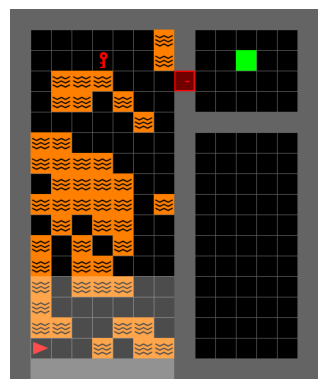

In [13]:
import matplotlib.pyplot as plt
from envs.lava_maze import lava_0, lava_1, lava_2
from envs.maze import make_maze_diff0, make_maze_diff1, make_maze_diff2, make_maze_diff3, lava_maze_0, lava_maze_1

env = lava_maze_key()
for _ in range(10000):
    env.reset()
frame = env.render()

plt.imshow(frame)
plt.axis('off') 
plt.show()

In [15]:
np.random.randint(low=0, high=1000000, size=(10,))

array([303933, 771729,  18887,  79593, 278024, 246515, 159038, 998298,
       151869, 423361])

In [16]:
from utils import map_envs
from config import *

names = ['empty',
 'multiroom',
 'big_multiroom',
 'key',
 'simple_key',
 'color',
 'locked_room',
 'four_rooms',
 'easy_memory',
 'memory',
 'medium_memory',
 'advanced_memory',
 'key_dungeon',
 'obstacle_key_simple',
 'obstacle_key',
 'obstacles',
 'obstacles_1',
 'obstacles_2',
 'combined',
 'lava_goal',
 'dungeon_1',
 'dungeon_2',
 'dungeon_3',
 'lava_0',
 'lava_1',
 'lava_2',
 'maze_0',
 'maze_1',
 'maze_2',
 'maze_3',
 'maze_4',
 'maze_5']

_, functions = map_envs(names)
now = 0

In [17]:
now += 1

<function make_room_env at 0x7f1af0453560>


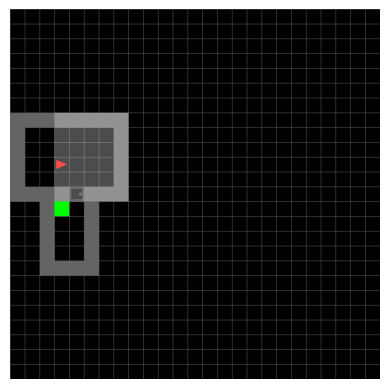

In [18]:
import matplotlib.pyplot as plt

env = functions[now]()
print(functions[now])
env.reset()
frame = env.render()

plt.imshow(frame)
plt.axis('off') 
plt.show()

In [19]:
import pandas as pd
from tbparse import SummaryReader

# Pfad zu deinem Log-Verzeichnis (wo die events... Dateien liegen)
log_dir = "logs/locked_b"

# SummaryReader liest das gesamte Verzeichnis
reader = SummaryReader(log_dir)

# Extrahiere alle Skalare (z.B. Loss, Accuracy) als DataFrame
df = reader.scalars

# Optional: Filtere nach einem bestimmten Tag
# df_loss = df[df['tag'] == 'train/loss']

print(df.head())

KeyboardInterrupt: 